# GPT-2 Recommendation on Semantic IDs

Treats recommendation as causal sequence modeling over SID tokens.
Each item occupies 3 consecutive tokens `(c1, c2, c3)`.
The model learns to predict the next item given a user's interaction history.

**Pipeline:**
1. Load trained RQ-VAE → assign SIDs to all items
2. Convert user histories to SID token sequences
3. Train GPT-2 style model with next-token prediction
4. Evaluate with constrained beam search → Recall@K, NDCG@K

In [1]:
pip install torch-geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 23.1 MB/s eta 0:00:00a 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os, glob, math
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from collections import defaultdict
from tqdm import tqdm

In [3]:
# ── Paths ─────────────────────────────────────────────────────────────────────
KAGGLE_BASE  = '/kaggle/input/datasets/qwerte123/hetero-data-updated-diffemb'
LOCAL_BASE   = r'C:\Users\Admin\Documents\GitHub\claude_plum\data'
BASE         = KAGGLE_BASE if os.path.exists(KAGGLE_BASE) else LOCAL_BASE

DATA_PATH    = os.path.join(BASE, 'heterodata_object12_updated.pt')
CKPT_DIR_IMP = os.path.join(BASE, 'checkpoints_improved')

LOCAL_SAVE   = r'C:\Users\Admin\Documents\GitHub\claude_plum\data\checkpoints_gpt2'
KAGGLE_SAVE  = '/kaggle/working/checkpoints_gpt2'
SAVE_DIR     = KAGGLE_SAVE if os.path.exists('/kaggle') else LOCAL_SAVE
os.makedirs(SAVE_DIR, exist_ok=True)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'device: {device}')

df = torch.load(DATA_PATH, weights_only=False, map_location='cpu')
print(df)

device: cuda
HeteroData(
  item={
    x=[12101, 100],
    text=[12101, 2],
    related=[12101],
    is_train=[12101],
  },
  (user, rated, item)={
    history={
      train={
        item_ID=[22363],
        item_ID_next=[22363],
        user_ID=[22363],
      },
      valid={
        item_ID=[22363, 15],
        item_ID_next=[22363],
        user_ID=[22363],
      },
      test={
        item_ID=[22363, 15],
        item_ID_next=[22363],
        user_ID=[22363],
      },
    },
  }
)


## 1. Load RQ-VAE and assign SIDs to all items

In [4]:
# ── Paste RQ-VAE definitions (must match training notebook exactly) ────────────
class Encoder(nn.Module):
    def __init__(self, input_dim, hidden_dims, output_dim):
        super().__init__()
        layers, dims = [], [input_dim] + list(hidden_dims) + [output_dim]
        for i, (a, b) in enumerate(zip(dims[:-1], dims[1:])):
            layers.append(nn.Linear(a, b, bias=True))
            if i < len(dims) - 2:
                layers.append(nn.LayerNorm(b))
                layers.append(nn.ReLU())
        self.net = nn.Sequential(*layers)
    def forward(self, x): return self.net(x)


class EMACodebook(nn.Module):
    def __init__(self, codebook_size, emb_dim, beta=0.25, ema_decay=0.99, epsilon=1e-4):
        super().__init__()
        self.codebook_size = codebook_size
        self.beta = beta; self.ema_decay = ema_decay; self.epsilon = epsilon
        emb = F.normalize(torch.randn(codebook_size, emb_dim), p=2, dim=1)
        self.register_buffer('emb',         emb)
        self.register_buffer('ema_count',   torch.ones(codebook_size))
        self.register_buffer('ema_weight',  emb.clone())
        self.register_buffer('initialized', torch.zeros(1, dtype=torch.bool))
    def forward(self, x):
        x_n    = F.normalize(x,        p=2, dim=1)
        code_n = F.normalize(self.emb, p=2, dim=1)
        ids    = (1.0 - x_n @ code_n.T).argmin(dim=1)
        emb    = self.emb[ids]
        commitment_loss = self.beta * F.mse_loss(x, emb.detach())
        return commitment_loss, x + (emb - x).detach(), ids


class RQVAE_Improved(nn.Module):
    def __init__(self, inp_size, hidden_sizes, embed_dim, n_layers,
                 codebook_size=256, beta=0.25, gamma=0.1, ema_decay=0.99, temperature=0.07):
        super().__init__()
        self.n_layers = n_layers
        self.enc = Encoder(inp_size, hidden_sizes, embed_dim)
        self.dec = Encoder(embed_dim, hidden_sizes[::-1], inp_size)
        self.codebooks = nn.ModuleList([
            EMACodebook(codebook_size, embed_dim, beta=beta, ema_decay=ema_decay)
            for _ in range(n_layers)
        ])
    def forward(self, x, related=None, is_self_pair=None):
        x_n     = F.normalize(x, p=2, dim=1)
        encoded = self.enc(x_n)
        r, sids = encoded, []
        for cb in self.codebooks:
            _, emb_st, ids = cb(r)
            r = r - emb_st.detach()
            sids.append(ids)
        return {'sids': sids}

In [6]:
# ── Load RQVAE checkpoint and compute SIDs ────────────────────────────────────
ckpts = sorted(glob.glob(os.path.join(BASE, 'rqvae_improved_s*.pt')))
assert ckpts, f'No checkpoint found in {CKPT_DIR_IMP}'
print(f'Using checkpoint: {ckpts[-1]}')

ckpt = torch.load(ckpts[-1], map_location='cpu', weights_only=False)
hp   = ckpt['hparams']

embeds  = df['item'].x
n_items = embeds.shape[0]

rqvae = RQVAE_Improved(
    inp_size=embeds.shape[1], hidden_sizes=[512, 256, 128],
    embed_dim=hp['embed_dim'], n_layers=hp['n_layers'],
    codebook_size=hp['codebook_size'], beta=hp['beta'],
).to(device)
rqvae.load_state_dict(ckpt['model_state'])
rqvae.eval()

# Assign SID to every item
item_sids   = {}   # item_id -> (c1, c2, c3)
sid_to_item = defaultdict(list)  # sid -> [item_ids]
with torch.no_grad():
    for i in range(n_items):
        x   = embeds[i].unsqueeze(0).to(device)
        out = rqvae(x)
        sid = tuple(s.item() for s in out['sids'])
        item_sids[i]      = sid
        sid_to_item[sid].append(i)

n_unique = len(sid_to_item)
n_colls  = sum(len(v) - 1 for v in sid_to_item.values())
cfr      = (n_items - n_colls) / n_items
print(f'Items: {n_items}  Unique SIDs: {n_unique}  Collisions: {n_colls}  CFR: {cfr:.4f}')

Using checkpoint: /kaggle/input/datasets/qwerte123/hetero-data-updated-diffemb/rqvae_improved_s5.pt
Items: 12101  Unique SIDs: 11031  Collisions: 1070  CFR: 0.9116


In [7]:
# ── Add 4th disambiguation codeword to resolve collisions ─────────────────────
# Items sharing the same (c1, c2, c3) are assigned c4 = 0, 1, 2, ... in item-id
# order within each collision group.  Non-collision items always get c4 = 0.
collision_counter = defaultdict(int)
item_sids_4 = {}
for i in range(n_items):
    sid3 = item_sids[i]           # (c1, c2, c3)
    c4   = collision_counter[sid3]
    collision_counter[sid3] += 1
    item_sids_4[i] = sid3 + (c4,) # (c1, c2, c3, c4)

MAX_C4   = max(collision_counter.values())  # 4th codebook size
item_sids = item_sids_4  # replace 3-tuples with 4-tuples everywhere

# Rebuild sid_to_item — every 4-tuple SID is now unique by construction
sid_to_item = defaultdict(list)
for i, sid in item_sids.items():
    sid_to_item[sid].append(i)

assert len(sid_to_item) == n_items, "4-tuple SIDs must be unique"
print(f'4-level SIDs: {n_items} unique  (was {n_unique} at 3 levels, {n_colls} collisions resolved)')
print(f'4th codebook size: {MAX_C4}')

4-level SIDs: 12101 unique  (was 11031 at 3 levels, 1070 collisions resolved)
4th codebook size: 12


## 2. Build vocabulary and convert histories to token sequences

Vocabulary layout (level-offset encoding):
```
PAD  = 0
BOS  = 1
c1 tokens: 2                 ..  2 + codebook_size - 1
c2 tokens: 2 + codebook_size ..  2 + 2*codebook_size - 1
c3 tokens: 2 + 2*codebook_size.. 2 + 3*codebook_size - 1
```
Total vocab size = 2 + 3 * codebook_size

In [8]:
# ── Vocabulary ────────────────────────────────────────────────────────────────
RQVAE_LEVELS  = hp['n_layers']        # 3  — levels from the RQ-VAE codebook
N_LEVELS      = RQVAE_LEVELS + 1      # 4  — +1 disambiguation level
CODEBOOK_SIZE = hp['codebook_size']   # 256 per RQ-VAE level
PAD_ID        = 0
BOS_ID        = 1
# Levels 0-2: CODEBOOK_SIZE codes each; level 3: MAX_C4 codes
LEVEL_OFFSET  = [2 + l * CODEBOOK_SIZE for l in range(RQVAE_LEVELS)] + \
                [2 + RQVAE_LEVELS * CODEBOOK_SIZE]
VOCAB_SIZE    = 2 + RQVAE_LEVELS * CODEBOOK_SIZE + MAX_C4
print(f'Vocab size: {VOCAB_SIZE}  Level offsets: {LEVEL_OFFSET}')
print(f'Level 3 (disambiguation) offset: {LEVEL_OFFSET[3]}  size: {MAX_C4}')

def item_to_tokens(item_id):
    """Convert item_id to list of N_LEVELS (4) tokens."""
    sid = item_sids[item_id]
    return [sid[l] + LEVEL_OFFSET[l] for l in range(N_LEVELS)]

def history_to_tokens(item_ids):
    """Convert a list of item_ids to a flat token sequence with BOS."""
    tokens = [BOS_ID]
    for iid in item_ids:
        tokens.extend(item_to_tokens(int(iid)))
    return tokens

# Quick sanity check
print('Item 0 SID:', item_sids[0], '  Tokens:', item_to_tokens(0))

Vocab size: 782  Level offsets: [2, 258, 514, 770]
Level 3 (disambiguation) offset: 770  size: 12
Item 0 SID: (163, 168, 123, 0)   Tokens: [165, 426, 637, 770]


In [9]:
# ── Build train / val / test splits from interaction data ─────────────────────
# train.item_ID  : list of lists (variable length per user — full training history)
# train.item_ID_next : [22363]  — target next item per user
#
# valid.item_ID  : [22363, 15]  — up to 15 most recent items, -1 padded
# valid.item_ID_next : [22363]  — validation target
#
# test.item_ID   : [22363, 15]  — context includes valid target, -1 padded
# test.item_ID_next  : [22363]  — test target

hist = df['user', 'rated', 'item'].history

def make_train_split():
    """Full variable-length histories from training set."""
    item_ids  = hist['train']['item_ID']        # list of lists
    item_next = hist['train']['item_ID_next']   # [n_users]
    samples = []
    for u in range(len(item_next)):
        ctx = [int(x) for x in item_ids[u] if int(x) >= 0]
        tgt = int(item_next[u])
        if not ctx or tgt < 0 or tgt >= n_items: continue
        samples.append((ctx, tgt))
    return samples

def make_eval_split(split_key):
    """Padded histories from valid / test sets."""
    item_ids  = hist[split_key]['item_ID']        # [n_users, 15]
    item_next = hist[split_key]['item_ID_next']   # [n_users]
    samples = []
    for u in range(len(item_next)):
        ctx = [int(x) for x in item_ids[u].tolist() if int(x) >= 0]
        tgt = int(item_next[u])
        if not ctx or tgt < 0 or tgt >= n_items: continue
        samples.append((ctx, tgt))
    return samples

samples_train = make_train_split()
samples_val   = make_eval_split('valid')
samples_test  = make_eval_split('test')

print(f'Train samples : {len(samples_train)}')
print(f'Val   samples : {len(samples_val)}')
print(f'Test  samples : {len(samples_test)}')

ctx_lens = [len(s[0]) for s in samples_train]
print(f'\nTrain context length — min:{min(ctx_lens)}  max:{max(ctx_lens)}  '
      f'mean:{sum(ctx_lens)/len(ctx_lens):.1f}')

Train samples : 22363
Val   samples : 22363
Test  samples : 22363

Train context length — min:3  max:202  mean:6.9


## 3. GPT-2 model

Key design choices vs standard GPT-2:
- **Level embeddings**: added to position embeddings so the model knows whether a token is `c1/c2/c3` regardless of absolute position
- **Weight tying**: `lm_head` shares weights with `token_emb` (standard in GPT-2, reduces params)
- **Pre-norm** (`norm_first=True`): more stable training
- **Causal attention mask**: auto-regressive, no future token leakage

In [10]:
class GPT2Rec(nn.Module):
    def __init__(self, vocab_size, d_model, n_heads, n_layers, max_seq_len,
                 n_levels, dropout=0.1):
        super().__init__()
        self.d_model     = d_model
        self.n_levels    = n_levels
        self.max_seq_len = max_seq_len

        self.tok_emb = nn.Embedding(vocab_size,   d_model, padding_idx=PAD_ID)
        self.pos_emb = nn.Embedding(max_seq_len,  d_model)
        # Level embedding: which codebook level this token belongs to (0..n_levels-1)
        # BOS gets level id 0 by convention.
        self.lvl_emb = nn.Embedding(n_levels, d_model)

        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads, dim_feedforward=4 * d_model,
            dropout=dropout, batch_first=True, norm_first=True,
        )
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=n_layers)
        self.ln_f    = nn.LayerNorm(d_model)
        self.lm_head = nn.Linear(d_model, vocab_size, bias=False)
        self.lm_head.weight = self.tok_emb.weight  # weight tying

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, std=0.02)
                if m.bias is not None: nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Embedding):
                nn.init.normal_(m.weight, std=0.02)
                if m.padding_idx is not None:
                    m.weight.data[m.padding_idx].zero_()

    def _level_ids(self, seq_len, device):
        """Return level ids [0, 0,1,2,3, 0,1,2,3, ...] for a sequence of length seq_len."""
        ids = torch.zeros(seq_len, dtype=torch.long, device=device)
        for pos in range(1, seq_len):
            ids[pos] = (pos - 1) % self.n_levels
        return ids.unsqueeze(0)  # [1, T]

    def forward(self, input_ids):
        B, T = input_ids.shape
        pos  = torch.arange(T, device=input_ids.device).unsqueeze(0)  # [1, T]
        lvl  = self._level_ids(T, input_ids.device).expand(B, -1)     # [B, T]

        x    = self.tok_emb(input_ids) + self.pos_emb(pos) + self.lvl_emb(lvl)

        causal = nn.Transformer.generate_square_subsequent_mask(T, device=input_ids.device)
        pad_m  = (input_ids == PAD_ID)  # [B, T]

        # Run layers manually, zeroing PAD positions after each layer.
        # This prevents NaN from all-masked PAD queries propagating to real
        # positions via 0 * NaN = NaN (IEEE 754) in subsequent layers.
        for layer in self.transformer.layers:
            x = layer(x, src_mask=causal, src_key_padding_mask=pad_m)
            x = x.masked_fill(pad_m.unsqueeze(-1), 0.0)

        if self.transformer.norm is not None:
            x = self.transformer.norm(x)
        x = self.ln_f(x)
        return self.lm_head(x)  # [B, T, vocab_size]

## 4. Dataset, collation, training loop

In [11]:
class RecDataset(Dataset):
    """
    Each sample: (context_items, target_item).
    Returns input_ids and labels for next-token prediction.

    input_ids : [BOS, c1_0,c2_0,c3_0, c1_1, ...  c1_{T-1},c2_{T-1},c3_{T-1}]
    labels    : [-100, ..., c1_T, c2_T, c3_T]   (only last 3 positions supervised)

    We supervise only the last item's tokens to keep the objective clean:
    given the full history, predict the next item.
    For richer training, we also supervise every next-item token in the sequence
    (teacher-forced on the history itself).
    """
    def __init__(self, samples, max_hist_len, n_levels, full_supervision=True):
        self.samples          = samples
        self.max_hist_len     = max_hist_len
        self.n_levels         = n_levels
        self.full_supervision = full_supervision   # supervise all positions vs only last item

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        ctx, tgt = self.samples[idx]
        # Truncate context to max_hist_len items
        ctx = ctx[-self.max_hist_len:]

        # Build input: [BOS, *ctx_tokens, *tgt_tokens]
        # Labels are input shifted left by 1; ignore BOS and ctx positions if not full_supervision
        inp = history_to_tokens(ctx) + item_to_tokens(tgt)
        inp = torch.tensor(inp, dtype=torch.long)

        # Labels: for full supervision supervise all next-token positions
        # For partial supervision, only supervise the last n_levels tokens (target item)
        lbl = inp[1:].clone()      # shifted left
        if not self.full_supervision:
            # mask everything except the last n_levels positions
            lbl[:-self.n_levels] = -100
        # Pad label to same length as inp (last position has no label)
        lbl = torch.cat([lbl, torch.tensor([-100])])
        return inp, lbl


def collate_fn(batch):
    """Left-pad sequences to the same length within a batch."""
    inps, lbls = zip(*batch)
    max_len    = max(x.shape[0] for x in inps)
    pad_inp, pad_lbl = [], []
    for inp, lbl in zip(inps, lbls):
        pad   = max_len - inp.shape[0]
        pad_inp.append(F.pad(inp, (pad, 0), value=PAD_ID))
        pad_lbl.append(F.pad(lbl, (pad, 0), value=-100))
    return torch.stack(pad_inp), torch.stack(pad_lbl)

In [12]:
# ── Hyperparameters ───────────────────────────────────────────────────────────
MAX_HIST_LEN = 20        # truncate long histories to this many items (train can be 35+)
D_MODEL      = 256
N_HEADS      = 8
N_LAYERS     = 4
DROPOUT      = 0.1
BATCH_SIZE   = 256
LR           = 1e-3
WARMUP_STEPS = 500
N_EPOCHS     = 50
BEAM_SIZE    = 32        # candidates per level in constrained beam search
EVAL_KS      = [1, 5, 10, 20]

MAX_SEQ_LEN  = 1 + (MAX_HIST_LEN + 1) * N_LEVELS  # BOS + (hist + target) * 3 tokens

# ── Datasets & loaders ───────────────────────────────────────────────────────
ds_train = RecDataset(samples_train, MAX_HIST_LEN, N_LEVELS, full_supervision=True)
ds_val   = RecDataset(samples_val,   MAX_HIST_LEN, N_LEVELS, full_supervision=False)
ds_test  = RecDataset(samples_test,  MAX_HIST_LEN, N_LEVELS, full_supervision=False)

dl_train = DataLoader(ds_train, batch_size=BATCH_SIZE, shuffle=True,  collate_fn=collate_fn, num_workers=0)
dl_val   = DataLoader(ds_val,   batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn, num_workers=0)

print(f'Train: {len(ds_train)}  Val: {len(ds_val)}  Test: {len(ds_test)}')
print(f'Max seq len: {MAX_SEQ_LEN}  Vocab: {VOCAB_SIZE}')

# ── Model ────────────────────────────────────────────────────────────────────
model = GPT2Rec(
    vocab_size=VOCAB_SIZE, d_model=D_MODEL, n_heads=N_HEADS,
    n_layers=N_LAYERS, max_seq_len=MAX_SEQ_LEN, n_levels=N_LEVELS, dropout=DROPOUT,
).to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nGPT2Rec parameters: {total_params:,}')
print(model)

Train: 22363  Val: 22363  Test: 22363
Max seq len: 85  Vocab: 782

GPT2Rec parameters: 3,382,528
GPT2Rec(
  (tok_emb): Embedding(782, 256, padding_idx=0)
  (pos_emb): Embedding(85, 256)
  (lvl_emb): Embedding(4, 256)
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-3): 4 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
        )
        (linear1): Linear(in_features=256, out_features=1024, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=1024, out_features=256, bias=True)
        (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (ln_f): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  (lm_he

/tmp/ipykernel_55/2020567884.py:19: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(enc_layer, num_layers=n_layers)


In [13]:
# ── Optimizer + cosine LR schedule with linear warmup ─────────────────────────
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=0.01)

total_steps  = N_EPOCHS * len(dl_train)

def lr_lambda(step):
    if step < WARMUP_STEPS:
        return step / max(1, WARMUP_STEPS)
    progress = (step - WARMUP_STEPS) / max(1, total_steps - WARMUP_STEPS)
    return max(0.05, 0.5 * (1.0 + math.cos(math.pi * progress)))  # cosine decay to 5% of LR

scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)


def train_epoch(model, loader, optimizer, scheduler, device):
    model.train()
    total_loss, n_batches = 0.0, 0
    for inp, lbl in tqdm(loader, leave=False, desc='train'):
        inp, lbl = inp.to(device), lbl.to(device)
        logits   = model(inp)                          # [B, T, V]
        loss     = F.cross_entropy(
            logits.view(-1, VOCAB_SIZE),
            lbl.view(-1),
            ignore_index=-100,
        )
        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()
        n_batches  += 1
    return total_loss / n_batches


def val_loss(model, loader, device):
    model.eval()
    total, n = 0.0, 0
    with torch.no_grad():
        for inp, lbl in loader:
            inp, lbl = inp.to(device), lbl.to(device)
            logits   = model(inp)
            loss     = F.cross_entropy(logits.view(-1, VOCAB_SIZE), lbl.view(-1), ignore_index=-100)
            total   += loss.item(); n += 1
    return total / n

In [14]:
# ── Training ──────────────────────────────────────────────────────────────────
best_val  = float('inf')
history   = defaultdict(list)

for epoch in range(1, N_EPOCHS + 1):
    tr_loss = train_epoch(model, dl_train, optimizer, scheduler, device)
    va_loss = val_loss(model, dl_val, device)
    history['train_loss'].append(tr_loss)
    history['val_loss'].append(va_loss)

    if va_loss < best_val:
        best_val = va_loss
        torch.save({
            'model_state': model.state_dict(),
            'optimizer_state': optimizer.state_dict(),
            'epoch': epoch,
            'val_loss': best_val,
            'hparams': dict(
                vocab_size=VOCAB_SIZE, d_model=D_MODEL, n_heads=N_HEADS,
                n_layers=N_LAYERS, max_seq_len=MAX_SEQ_LEN, n_levels=N_LEVELS,
                dropout=DROPOUT, codebook_size=CODEBOOK_SIZE,
            ),
        }, os.path.join(SAVE_DIR, 'gpt2rec_best.pt'))

    if epoch % 5 == 0:
        print(f'Epoch {epoch:3d}/{N_EPOCHS} | '
              f'train={tr_loss:.4f}  val={va_loss:.4f}  '
              f'lr={scheduler.get_last_lr()[0]:.2e}  best_val={best_val:.4f}')

print('\nTraining complete.')

train:   0%|          | 0/88 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:823: UserWarning: Support for mismatched src_key_padding_mask and src_mask is deprecated. Use same type for both instead.
  src_key_padding_mask = F._canonical_mask(


Epoch   5/50 | train=2.7442  val=2.5258  lr=8.80e-04  best_val=2.5258


Epoch  10/50 | train=2.1099  val=1.9697  lr=9.77e-04  best_val=1.9697


Epoch  15/50 | train=1.9613  val=1.8313  lr=8.95e-04  best_val=1.8313


Epoch  20/50 | train=1.8526  val=1.7166  lr=7.64e-04  best_val=1.7166


...

Epoch  30/50 | train=1.6539  val=1.5457  lr=4.24e-04  best_val=1.5457


Epoch  35/50 | train=1.5663  val=1.4774  lr=2.57e-04  best_val=1.4774


Epoch  40/50 | train=1.4996  val=1.4385  lr=1.20e-04  best_val=1.4385


Epoch  45/50 | train=1.4637  val=1.4181  lr=5.00e-05  best_val=1.4168


Epoch  50/50 | train=1.4518  val=1.4084  lr=5.00e-05  best_val=1.4084

Training complete.


## 5. Constrained beam search evaluation

For each user, rank all items by the sum of log-probabilities of their SID tokens:
```
log P(item_i | history) = log P(c1_i | h) + log P(c2_i | h, c1_i) + log P(c3_i | h, c1_i, c2_i)
```
Using a **SID trie** so we only score actually valid SID combinations (never generated items receive score -inf).

In [15]:
# ── Build SID trie ────────────────────────────────────────────────────────────
# trie[c1][c2][c3][c4] = item_id  (4-tuple SIDs are unique by construction)
trie = {}
for (c1, c2, c3, c4), item_ids in sid_to_item.items():
    trie.setdefault(c1, {}).setdefault(c2, {}).setdefault(c3, {})[c4] = item_ids[0]

n_c1c2  = sum(len(v)    for v in trie.values())
n_c1c2c3 = sum(len(w)   for v in trie.values() for w in v.values())
print(f'Trie: {len(trie)} c1 nodes | {n_c1c2} (c1,c2) | {n_c1c2c3} (c1,c2,c3) | {n_items} leaves')


@torch.no_grad()
def score_next_item(model, context_ids, trie, beam_size, device):
    """
    Returns a list of (score, item_id) sorted descending.
    Uses 4-step constrained beam search over the SID trie.
    """
    model.eval()
    ctx = context_ids.unsqueeze(0).to(device)  # [1, T]

    def extend(seq, code, level):
        tok = torch.tensor([[code + LEVEL_OFFSET[level]]], device=device)
        return torch.cat([seq, tok], dim=1)

    # ── Step 1: score all valid c1 tokens ────────────────────────────────────
    logits_c1 = model(ctx)[0, -1, :]
    c1_scores  = {c1: logits_c1[c1 + LEVEL_OFFSET[0]].item() for c1 in trie}
    top_c1     = sorted(c1_scores, key=c1_scores.__getitem__, reverse=True)[:beam_size]

    # ── Step 2: extend each c1 beam with valid c2 ────────────────────────────
    beams2 = []
    for c1 in top_c1:
        logits_c2 = model(extend(ctx, c1, 0))[0, -1, :]
        for c2 in trie[c1]:
            beams2.append((c1_scores[c1] + logits_c2[c2 + LEVEL_OFFSET[1]].item(), c1, c2))
    beams2.sort(reverse=True); beams2 = beams2[:beam_size]

    # ── Step 3: extend top (c1,c2) beams with valid c3 ───────────────────────
    beams3 = []
    for s2, c1, c2 in beams2:
        logits_c3 = model(extend(extend(ctx, c1, 0), c2, 1))[0, -1, :]
        for c3 in trie[c1][c2]:
            beams3.append((s2 + logits_c3[c3 + LEVEL_OFFSET[2]].item(), c1, c2, c3))
    beams3.sort(reverse=True); beams3 = beams3[:beam_size]

    # ── Step 4: extend top (c1,c2,c3) beams with valid c4 (disambiguation) ──
    results = []
    for s3, c1, c2, c3 in beams3:
        ctx3      = extend(extend(extend(ctx, c1, 0), c2, 1), c3, 2)
        logits_c4 = model(ctx3)[0, -1, :]
        for c4, item_id in trie[c1][c2][c3].items():
            results.append((s3 + logits_c4[c4 + LEVEL_OFFSET[3]].item(), item_id))

    results.sort(reverse=True)
    return results

Trie: 251 c1 nodes | 7126 (c1,c2) | 11031 (c1,c2,c3) | 12101 leaves


In [19]:
# ── Batched beam search (~24x faster than the single-sequence version) ─────────
# The original score_next_item runs one forward pass per beam per step:
#   1 + beam_size + beam_size + beam_size = 97 passes per user.
# This version packs all beams at each step into a single batched forward pass:
#   4 passes per user regardless of beam_size.

@torch.no_grad()
def score_next_item_batched(model, context_ids, trie, beam_size, device):
    """
    Batched 4-step constrained beam search.
    Returns a list of (score, item_id) sorted descending.
    """
    model.eval()
    ctx = context_ids.to(device)  # [T]

    # ── Step 1: score all valid c1 (single pass) ─────────────────────────────
    logits_c1 = model(ctx.unsqueeze(0))[0, -1, :]
    c1_scores  = {c1: logits_c1[c1 + LEVEL_OFFSET[0]].item() for c1 in trie}
    top_c1     = sorted(c1_scores, key=c1_scores.__getitem__, reverse=True)[:beam_size]

    # ── Step 2: batch all c1 beams, score c2 ─────────────────────────────────
    c1_toks = torch.tensor([c1 + LEVEL_OFFSET[0] for c1 in top_c1], device=device)
    batch2  = torch.cat([ctx.unsqueeze(0).expand(len(top_c1), -1),
                         c1_toks.unsqueeze(1)], dim=1)           # [B1, T+1]
    logits2 = model(batch2)[:, -1, :]                            # [B1, V]

    beams2 = []
    for i, c1 in enumerate(top_c1):
        for c2 in trie[c1]:
            beams2.append((c1_scores[c1] + logits2[i, c2 + LEVEL_OFFSET[1]].item(), c1, c2))
    beams2.sort(reverse=True); beams2 = beams2[:beam_size]

    # ── Step 3: batch all (c1,c2) beams, score c3 ────────────────────────────
    c1c2_toks = torch.tensor([[c1 + LEVEL_OFFSET[0], c2 + LEVEL_OFFSET[1]]
                               for _, c1, c2 in beams2], device=device)  # [B2, 2]
    batch3  = torch.cat([ctx.unsqueeze(0).expand(len(beams2), -1),
                         c1c2_toks], dim=1)                               # [B2, T+2]
    logits3 = model(batch3)[:, -1, :]                                     # [B2, V]

    beams3 = []
    for i, (s2, c1, c2) in enumerate(beams2):
        for c3 in trie[c1][c2]:
            beams3.append((s2 + logits3[i, c3 + LEVEL_OFFSET[2]].item(), c1, c2, c3))
    beams3.sort(reverse=True); beams3 = beams3[:beam_size]

    # ── Step 4: batch all (c1,c2,c3) beams, score c4 ─────────────────────────
    c123_toks = torch.tensor([[c1 + LEVEL_OFFSET[0],
                                c2 + LEVEL_OFFSET[1],
                                c3 + LEVEL_OFFSET[2]]
                               for _, c1, c2, c3 in beams3], device=device)  # [B3, 3]
    batch4  = torch.cat([ctx.unsqueeze(0).expand(len(beams3), -1),
                         c123_toks], dim=1)                                    # [B3, T+3]
    logits4 = model(batch4)[:, -1, :]                                          # [B3, V]

    results = []
    for i, (s3, c1, c2, c3) in enumerate(beams3):
        for c4, item_id in trie[c1][c2][c3].items():
            results.append((s3 + logits4[i, c4 + LEVEL_OFFSET[3]].item(), item_id))

    results.sort(reverse=True)
    return results


print('Evaluating with batched beam search...')
val_metrics_fast  = evaluate(samples_val,  model, trie, BEAM_SIZE, EVAL_KS, device,
                              desc='val (batched)', score_fn=score_next_item_batched)
test_metrics_fast = evaluate(samples_test, model, trie, BEAM_SIZE, EVAL_KS, device,
                              desc='test (batched)', score_fn=score_next_item_batched)

results_fast = pd.DataFrame({'Val': val_metrics_fast, 'Test': test_metrics_fast}).T
print('\n' + results_fast.to_string())

Evaluating with batched beam search...



      Recall@1  Recall@5  Recall@10  Recall@20  NDCG@1  NDCG@5  NDCG@10  NDCG@20  n_users
Val     0.0230    0.0851     0.1435     0.2311  0.0230  0.0537   0.0724   0.0945  22363.0
Test    0.0061    0.0238     0.0412     0.0686  0.0061  0.0149   0.0205   0.0274  22363.0


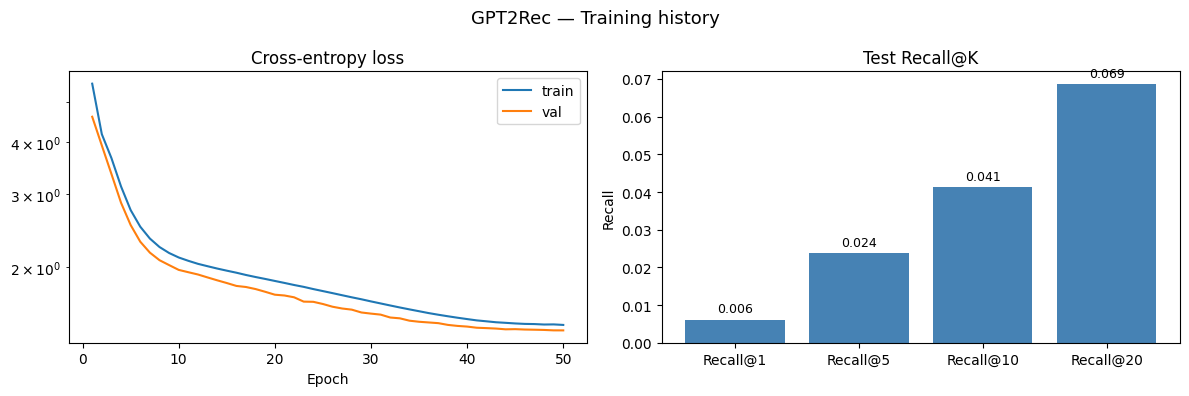


Final test metrics:
  Recall@1: 0.0061
  Recall@5: 0.0238
  Recall@10: 0.0412
  Recall@20: 0.0686
  NDCG@1: 0.0061
  NDCG@5: 0.0149
  NDCG@10: 0.0205
  NDCG@20: 0.0274
  n_users: 22363


In [22]:
# ── Training curves ───────────────────────────────────────────────────────────
import matplotlib.pyplot as plt

epochs = range(1, len(history['train_loss']) + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('GPT2Rec — Training history', fontsize=13)

axes[0].plot(epochs, history['train_loss'], label='train')
axes[0].plot(epochs, history['val_loss'],   label='val')
axes[0].set_title('Cross-entropy loss'); axes[0].set_xlabel('Epoch')
axes[0].legend(); axes[0].set_yscale('log')

# Recall@K bar chart from test metrics
rec_keys = [f'Recall@{k}' for k in EVAL_KS]
rec_vals = [test_metrics_fast[k] for k in rec_keys]
axes[1].bar(rec_keys, rec_vals, color='steelblue')
axes[1].set_title('Test Recall@K'); axes[1].set_ylabel('Recall')
for i, v in enumerate(rec_vals):
    axes[1].text(i, v + 0.002, f'{v:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'gpt2rec_results.png'), dpi=150, bbox_inches='tight')
plt.show()

print('\nFinal test metrics:')
for k, v in test_metrics_fast.items():
    print(f'  {k}: {v}')